# Descriptives and Within-Subject Analyses

This notebook analyzes survey data collected from 108 participants.

- **T1**: Baseline
- **T2**: After the information intervention
- **T3**: After the EFT intervention


In [28]:
# All imports used in this notebook
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multitest import multipletests

## 1. Load data

In [29]:
# Put DatasetExperiment.csv in the same folder as this notebook
DataSet = pd.read_csv("DatasetExperiment.csv")

# Convert all column names to strings and remove whitespace.
DataSet.columns = DataSet.columns.astype(str).str.strip()

# Display all columns in the DataFrame output.
pd.set_option('display.max_columns', None)

## 2. Define variables

In [30]:
# Demographic variables
IdColumn = "ResponseId_x"

CategoricalDemographics = [
    "Location", "Gender", "Education", "Greywater",
    "Toilet button", "Showerhead", "Watersaving toilet"
]
NumericDemographics = ["age", "HouseholdNumber"]

# T1 = baseline, T2 = after information intervention, T3 = after EFT intervention
TimePointLabels = ["T1", "T2", "T3"]
TimePointNumbers = {"T1": "1", "T2": "2", "T3": "3"}

# Water-saving behaviours
BehaviourNames = [
    "NumberOfShowers",
    "ShowerDuration",
    "NumberOfWashing",
    "Turnwateroff",
    "WashMode",
    "FullWash",
    "FlushButton"
]

def BehaviourColumnName(TimePointLabel, BehaviourName):
    """Survey columns are written like '2:ShowerDuration'."""
    return f"{TimePointNumbers[TimePointLabel]}:{BehaviourName}"

# {T1: column, T2: column, T3: column}
BehaviourColumnMap = {
    BehaviourName: {
        TimePointLabel: BehaviourColumnName(TimePointLabel, BehaviourName)
        for TimePointLabel in TimePointLabels
        if BehaviourColumnName(TimePointLabel, BehaviourName) in DataSet.columns
    }
    for BehaviourName in BehaviourNames
}

condition_map = {
    "1": "Baseline condition",
    "2": "Information condition",
    "3": "EFT condition"
}

variable_map = {
    "NumberOfShowers": "Number of showers",
    "ShowerDuration": "Shower duration (minutes)",
    "NumberOfWashing": "Washing machine use",
    "Turnwateroff": "Turning water off",
    "WashMode": "Washing mode",
    "FullWash": "Full wash cycle",
    "FlushButton": "Toilet flush usage",
    "age": "Age",
    "HouseholdNumber": "Household size",
    "log10_k_T1": "Log10 k (T1)",
    "log10_k_T2": "Log10 k (T2)",
    "log10_k_T3": "Log10 k (T3)"
}

BehaviourColumnMap

{'NumberOfShowers': {'T1': '1:NumberOfShowers',
  'T2': '2:NumberOfShowers',
  'T3': '3:NumberOfShowers'},
 'ShowerDuration': {'T1': '1:ShowerDuration',
  'T2': '2:ShowerDuration',
  'T3': '3:ShowerDuration'},
 'NumberOfWashing': {'T1': '1:NumberOfWashing',
  'T2': '2:NumberOfWashing',
  'T3': '3:NumberOfWashing'},
 'Turnwateroff': {'T1': '1:Turnwateroff',
  'T2': '2:Turnwateroff',
  'T3': '3:Turnwateroff'},
 'WashMode': {'T1': '1:WashMode', 'T2': '2:WashMode', 'T3': '3:WashMode'},
 'FullWash': {'T1': '1:FullWash', 'T2': '2:FullWash', 'T3': '3:FullWash'},
 'FlushButton': {'T1': '1:FlushButton',
  'T2': '2:FlushButton',
  'T3': '3:FlushButton'}}

In [39]:
# Normality test for k_T1, k_T2 and k_T3
columns = ['k_T1', 'k_T2', 'k_T3']
results = []

for column in columns:
    data = pd.to_numeric(DataSet[column], errors='coerce').dropna()
    stat, p = stats.shapiro(data)
    results.append({'Variable': column, 'N': len(data), 'W (Shapiro-Wilk)': round(stat, 4), 'p-value': round(p, 4), 
    'Normally distributed?': 'Yes' if p > 0.05 else 'No'})

print(pd.DataFrame(results))

# Delay discounting: k is the raw rate parameter, but it is strongly right-skewed.
# log10(k) is the variable actually used in all analyses in this notebook.
for TimePointLabel in TimePointLabels:
    SourceColumn = f"k_{TimePointLabel}"
    DataSet[f"log10_k_{TimePointLabel}"] = np.log10(DataSet[SourceColumn])

LogKColumnMap = {
    "log10_k": {TimePointLabel: f"log10_k_{TimePointLabel}" for TimePointLabel in TimePointLabels}
}

# All repeated-measures variables analyzed in this notebook: behaviours + log10(k)
RepeatedMeasuresColumnMap = {**BehaviourColumnMap, **LogKColumnMap}

RepeatedMeasuresColumnMap

  Variable    N  W (Shapiro-Wilk)  p-value Normally distributed?
0     k_T1  108            0.1851      0.0                    No
1     k_T2  108            0.2104      0.0                    No
2     k_T3  108            0.2609      0.0                    No


{'NumberOfShowers': {'T1': '1:NumberOfShowers',
  'T2': '2:NumberOfShowers',
  'T3': '3:NumberOfShowers'},
 'ShowerDuration': {'T1': '1:ShowerDuration',
  'T2': '2:ShowerDuration',
  'T3': '3:ShowerDuration'},
 'NumberOfWashing': {'T1': '1:NumberOfWashing',
  'T2': '2:NumberOfWashing',
  'T3': '3:NumberOfWashing'},
 'Turnwateroff': {'T1': '1:Turnwateroff',
  'T2': '2:Turnwateroff',
  'T3': '3:Turnwateroff'},
 'WashMode': {'T1': '1:WashMode', 'T2': '2:WashMode', 'T3': '3:WashMode'},
 'FullWash': {'T1': '1:FullWash', 'T2': '2:FullWash', 'T3': '3:FullWash'},
 'FlushButton': {'T1': '1:FlushButton',
  'T2': '2:FlushButton',
  'T3': '3:FlushButton'},
 'log10_k': {'T1': 'log10_k_T1', 'T2': 'log10_k_T2', 'T3': 'log10_k_T3'}}

## 3. Descriptive statistics

In [32]:
def NumericDescriptives(Data, Columns):
    """Calculate N, mean, SD, median, quartiles, IQR, min and max for each numeric column."""
    Rows = []
    for Column in Columns:
        Values = pd.to_numeric(Data[Column], errors="coerce").dropna()
        Q1 = Values.quantile(0.25)
        Q3 = Values.quantile(0.75)

        Rows.append({
            "Variable": Column,
            "N": int(Values.count()),
            "Mean": round(Values.mean(), 3),
            "SD": round(Values.std(ddof=1), 3),
            "Median": round(Values.median(), 3),
            "Q1": round(Q1, 3),
            "Q3": round(Q3, 3),
            "IQR": round(Q3 - Q1, 3),
            "Min": Values.min(),
            "Max": Values.max()
        })

    return pd.DataFrame(Rows)

# Select all numeric columns
NumericColumns = DataSet.select_dtypes(include="number").columns.tolist()

# Calculate descriptives
DescriptivesTable = NumericDescriptives(DataSet, NumericColumns)

# Display results
DescriptivesTable

,Variable,N,Mean,SD,Median,Q1,Q3,IQR,Min,Max
0,HouseholdNumber,108,2.778,1.682,2.000,2.000,4.000,2.000,1.000000,10.000000
1,1:NumberOfShowers,108,5.435,2.404,5.000,4.000,7.000,3.000,1.000000,17.000000
2,1:ShowerDuration,108,11.667,8.316,10.000,6.000,15.000,9.000,1.000000,70.000000
3,1:Turnwateroff,108,2.361,1.437,2.000,1.000,4.000,3.000,1.000000,5.000000
4,1:NumberOfWashing,108,3.352,2.236,3.000,2.000,4.000,2.000,0.500000,14.000000
5,1:WashMode,108,3.370,1.242,4.000,2.750,4.000,1.250,1.000000,5.000000
6,1:FullWash,108,4.056,1.040,4.000,4.000,5.000,1.000,1.000000,5.000000
7,1:FlushButton,108,3.731,1.337,4.000,3.000,5.000,2.000,1.000000,5.000000
8,2:NumberOfShowers,108,5.204,2.266,5.000,3.750,7.000,3.250,1.000000,14.000000
9,2:ShowerDuration,108,10.398,8.187,10.000,5.000,10.500,5.500,1.000000,70.000000


In [33]:
# Descriptive statistics for the categorical demographic variables
CategoricalRows = []

for Column in CategoricalDemographics:
    Counts = DataSet[Column].value_counts(dropna=False)
    Total = Counts.sum()
    ModeValue = Counts.idxmax()

    for Value, N in Counts.items():
        ValueLabel = "Missing" if pd.isna(Value) else Value
        CategoricalRows.append({
            "Variable": Column,
            "Category": ValueLabel,
            "N": int(N),
            "Percentage": round(100 * N / Total, 1),
            "Mode": ValueLabel if Value == ModeValue else ""
        })

CategoricalDescriptives = pd.DataFrame(CategoricalRows)
CategoricalDescriptives = CategoricalDescriptives.sort_values(
    ["Variable", "N"], ascending=[True, False]
)


CategoricalDescriptives


,Variable,Category,N,Percentage,Mode
15,Education,Bachelor’s degree (HBO or WO),47,43.5,Bachelor’s degree (HBO or WO)
16,Education,Master’s degree or higher (HBO or WO),25,23.1,
17,Education,Secondary education (High school),19,17.6,
18,Education,Vocational education (MBO),14,13.0,
19,Education,Other,2,1.9,
20,Education,No formal education,1,0.9,
11,Gender,Woman,53,49.1,Woman
12,Gender,Man,52,48.1,
13,Gender,Prefer not to say,2,1.9,
14,Gender,Non-binary,1,0.9,


## 4. Demographic charts

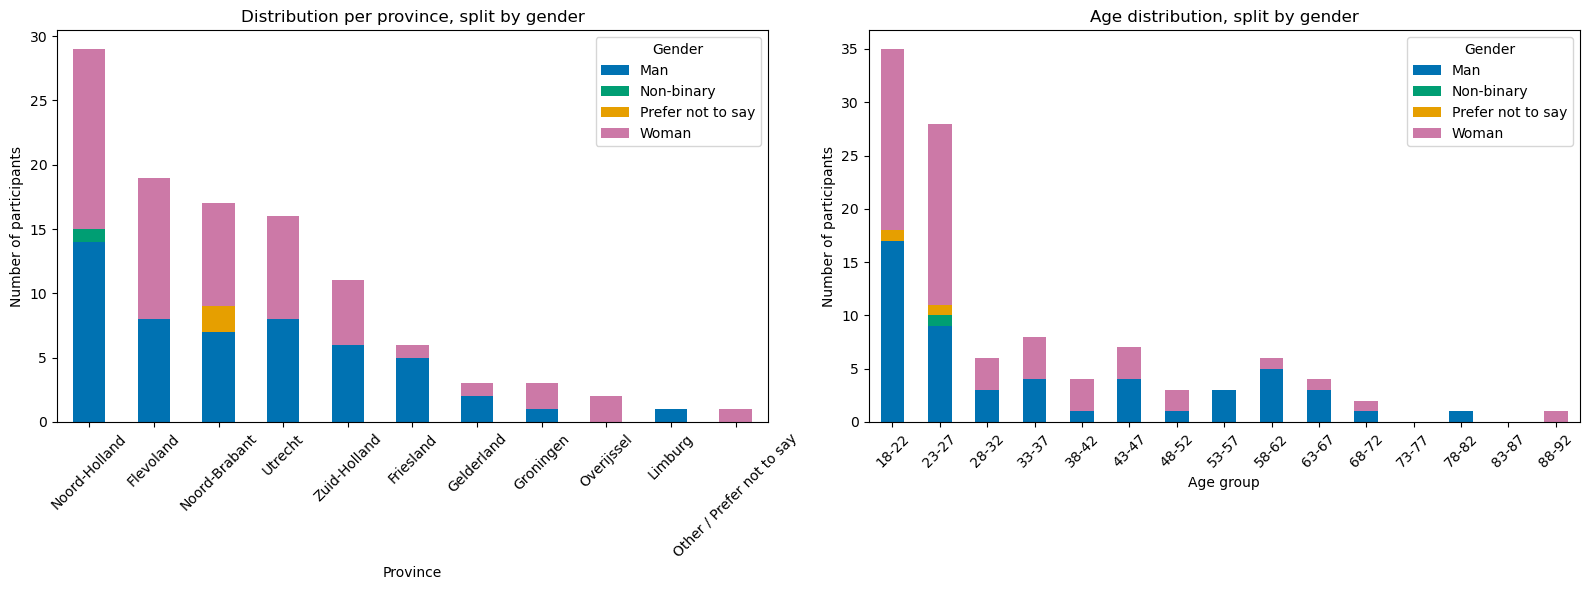

In [34]:
GenderColors = {
    "Man": "#0072B2",
    "Woman": "#CC79A7",
    "Non-binary": "#009E73",
    "Prefer not to say": "#E69F00"
}

Figure, Axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: province, split by gender
ProvinceGenderTable = pd.crosstab(DataSet["Location"], DataSet["Gender"])
ProvinceGenderTable = ProvinceGenderTable.loc[
    ProvinceGenderTable.sum(axis=1).sort_values(ascending=False).index
]
BarColors = [GenderColors.get(Column, "#4e8385") for Column in ProvinceGenderTable.columns]

ProvinceGenderTable.plot(kind="bar", stacked=True, ax=Axes[0], color=BarColors)
Axes[0].set_title("Distribution per province, split by gender")
Axes[0].set_xlabel("Province")
Axes[0].set_ylabel("Number of participants")
Axes[0].tick_params(axis="x", rotation=45)
Axes[0].legend(title="Gender")

# Panel 2: age group, split by gender
CleanData = DataSet.dropna(subset=["age", "Gender", "Location"]).copy()

BinSize = 5
MinAge = 18
MaxAge = int(CleanData["age"].max()) + BinSize
AgeBins = list(range(MinAge, MaxAge, BinSize))
AgeLabels = [f"{Bin}-{Bin + BinSize - 1}" for Bin in AgeBins[:-1]]

CleanData["AgeGroup"] = pd.cut(
    CleanData["age"], bins=AgeBins, labels=AgeLabels, include_lowest=True, right=False
)

AgeGenderTable = pd.crosstab(CleanData["AgeGroup"], CleanData["Gender"])
AgeGenderTable = AgeGenderTable.reindex(AgeLabels, fill_value=0)
BarColors = [GenderColors.get(Column, "#4e8385") for Column in AgeGenderTable.columns]

AgeGenderTable.plot(kind="bar", stacked=True, ax=Axes[1], color=BarColors)
Axes[1].set_title("Age distribution, split by gender")
Axes[1].set_xlabel("Age group")
Axes[1].set_ylabel("Number of participants")
Axes[1].tick_params(axis="x", rotation=45)
Axes[1].legend(title="Gender")

plt.tight_layout()
plt.savefig("gender_distributions.pdf", bbox_inches="tight")
plt.show()

## 5. Check normality

In [35]:
# Normaliteitstest voor alle repeated-measures variabelen (gedragingen + log10_k + k)
def ShapiroTest(Values):
    """Run Shapiro-Wilk test."""
    Values = pd.to_numeric(Values, errors="coerce").dropna()
    if len(Values) < 3:
        return np.nan, np.nan
    return stats.shapiro(Values)

RawKColumnMap = {
    "k": {TimePointLabel: f"k_{TimePointLabel}" for TimePointLabel in TimePointLabels}
}

AllColumnsToTest = {**RepeatedMeasuresColumnMap, **RawKColumnMap}

NormalityRows = []

for VariableName, TimePointColumns in AllColumnsToTest.items():
    for TimePointLabel, Column in TimePointColumns.items():
        W, P = ShapiroTest(DataSet[Column])
        NormalityRows.append({"Variable": VariableName,"Condition": TimePointLabel, "N": int(DataSet[Column].dropna().shape[0]),
        "Shapiro_W": round(W, 4) if not np.isnan(W) else np.nan, "p_value": round(P, 4) if not np.isnan(P) else np.nan,
        "Normal (p > .05)": (P >= 0.05) if not np.isnan(P) else np.nan})

NormalityTable = pd.DataFrame(NormalityRows)
NormalityTable

,Variable,Condition,N,Shapiro_W,p_value,Normal (p > .05)
0,NumberOfShowers,T1,108,0.8480,0.0000,False
1,NumberOfShowers,T2,108,0.8785,0.0000,False
2,NumberOfShowers,T3,108,0.8582,0.0000,False
3,ShowerDuration,T1,108,0.7056,0.0000,False
4,ShowerDuration,T2,108,0.6606,0.0000,False
5,ShowerDuration,T3,108,0.5954,0.0000,False
6,NumberOfWashing,T1,108,0.8319,0.0000,False
7,NumberOfWashing,T2,108,0.8116,0.0000,False
8,NumberOfWashing,T3,108,0.8066,0.0000,False
9,Turnwateroff,T1,108,0.8203,0.0000,False


## 6. Paired tests with multiple-comparison correction and effect sizes

In [44]:
ComparisonPairs = [("T1", "T2"), ("T2", "T3"), ("T1", "T3")]

FriedmanResults = []

for VariableName, ColumnsForVariable in RepeatedMeasuresColumnMap.items():
    if not all(t in ColumnsForVariable for t in ["T1", "T2", "T3"]):
        continue

    Data = pd.DataFrame({
        t: pd.to_numeric(DataSet[ColumnsForVariable[t]], errors="coerce")
        for t in ["T1", "T2", "T3"]}).dropna()

    Statistic, PValue = stats.friedmanchisquare(Data["T1"], Data["T2"], Data["T3"])

    FriedmanResults.append({"Variable": VariableName, "N": len(Data),
    "Friedman_chi2": round(Statistic, 4),"p_value": round(PValue, 4),})

FriedmanTable = pd.DataFrame(FriedmanResults)
display(FriedmanTable)

def WilcoxonPairedTest(ValuesA, ValuesB):
    ValuesA = pd.to_numeric(ValuesA, errors="coerce")
    ValuesB = pd.to_numeric(ValuesB, errors="coerce")
    PairedData = pd.DataFrame({"A": ValuesA, "B": ValuesB}).dropna()
    N = len(PairedData)

    Diff = PairedData["B"] - PairedData["A"]
    N_nonzero = int((Diff != 0).sum())

    Result = stats.wilcoxon(PairedData["B"], PairedData["A"], zero_method="wilcox", mode="approx")

    EffectSizeR = abs(Result.zstatistic) / np.sqrt(N_nonzero)

    return {
        "N": N, "N_nonzero": N_nonzero, "Statistic": round(Result.statistic, 4),
        "p_uncorrected": Result.pvalue, "MeanDifference": Diff.mean(), "MedianDifference": Diff.median(),
        "EffectSize_r": EffectSizeR}

,Variable,N,Friedman_chi2,p_value
0,NumberOfShowers,108,34.5645,0.0000
1,ShowerDuration,108,80.7902,0.0000
2,NumberOfWashing,108,35.1092,0.0000
3,Turnwateroff,108,81.3119,0.0000
4,WashMode,108,53.5707,0.0000
5,FullWash,108,33.8000,0.0000
6,FlushButton,108,33.0385,0.0000
7,log10_k,108,6.0905,0.0476


In [37]:
PairedTestResults = []

for VariableName, ColumnsForVariable in RepeatedMeasuresColumnMap.items():
    VariableResults = []

    for TimeA, TimeB in ComparisonPairs:
        if TimeA in ColumnsForVariable and TimeB in ColumnsForVariable:
            ColumnA = ColumnsForVariable[TimeA]
            ColumnB = ColumnsForVariable[TimeB]

            TestResult = WilcoxonPairedTest(DataSet[ColumnA], DataSet[ColumnB])
            TestResult.update({"Variable": VariableName, "Comparison": f"{TimeA} -> {TimeB}", 
            "ColumnA": ColumnA, "ColumnB": ColumnB})
            VariableResults.append(TestResult)

    PValues = [Result["p_uncorrected"] for Result in VariableResults]

    if len(PValues) > 0:
        Rejected, HolmPValues, _, _ = multipletests(PValues, alpha=0.05, method="holm")
    else:
        Rejected, HolmPValues = [], []

    for Result, IsRejected, HolmPValue in zip(VariableResults, Rejected, HolmPValues):
        Result["p_holm"] = round(HolmPValue, 4)
        Result["Significant_Holm_.05"] = bool(IsRejected)
        PairedTestResults.append(Result)

PairedTestResultsTable = pd.DataFrame(PairedTestResults)

ColumnOrder = ["Variable", "Comparison", "ColumnA", "ColumnB", "N", "Statistic",
               "p_uncorrected", "p_holm", "Significant_Holm_.05","MeanDifference", "MedianDifference", "EffectSize_r"
]
PairedTestResultsTable = PairedTestResultsTable[ColumnOrder]

display(PairedTestResultsTable)

,Variable,Comparison,ColumnA,ColumnB,N,Statistic,p_uncorrected,p_holm,Significant_Holm_.05,MeanDifference,MedianDifference,EffectSize_r
0,NumberOfShowers,T1 -> T2,1:NumberOfShowers,2:NumberOfShowers,108,30.0,0.0012,0.0024,True,-0.2315,0.0,0.6906
1,NumberOfShowers,T2 -> T3,2:NumberOfShowers,3:NumberOfShowers,108,54.0,0.0015,0.0024,True,-0.2500,0.0,0.6234
2,NumberOfShowers,T1 -> T3,1:NumberOfShowers,3:NumberOfShowers,108,70.0,0.0000,0.0000,True,-0.4815,0.0,0.7146
3,ShowerDuration,T1 -> T2,1:ShowerDuration,2:ShowerDuration,108,19.0,0.0000,0.0000,True,-1.2685,0.0,0.8495
4,ShowerDuration,T2 -> T3,2:ShowerDuration,3:ShowerDuration,108,47.0,0.0000,0.0000,True,-1.2500,0.0,0.7559
5,ShowerDuration,T1 -> T3,1:ShowerDuration,3:ShowerDuration,108,26.5,0.0000,0.0000,True,-2.5185,-2.0,0.8513
6,NumberOfWashing,T1 -> T2,1:NumberOfWashing,2:NumberOfWashing,108,43.5,0.0012,0.0024,True,-0.2037,0.0,0.6608
7,NumberOfWashing,T2 -> T3,2:NumberOfWashing,3:NumberOfWashing,108,36.0,0.0031,0.0031,True,-0.1574,0.0,0.6445
8,NumberOfWashing,T1 -> T3,1:NumberOfWashing,3:NumberOfWashing,108,77.5,0.0000,0.0000,True,-0.3611,0.0,0.6986
9,Turnwateroff,T1 -> T2,1:Turnwateroff,2:Turnwateroff,108,92.5,0.0000,0.0000,True,0.5556,0.0,0.7564


## 7. Visual overview of T1, T2, T3

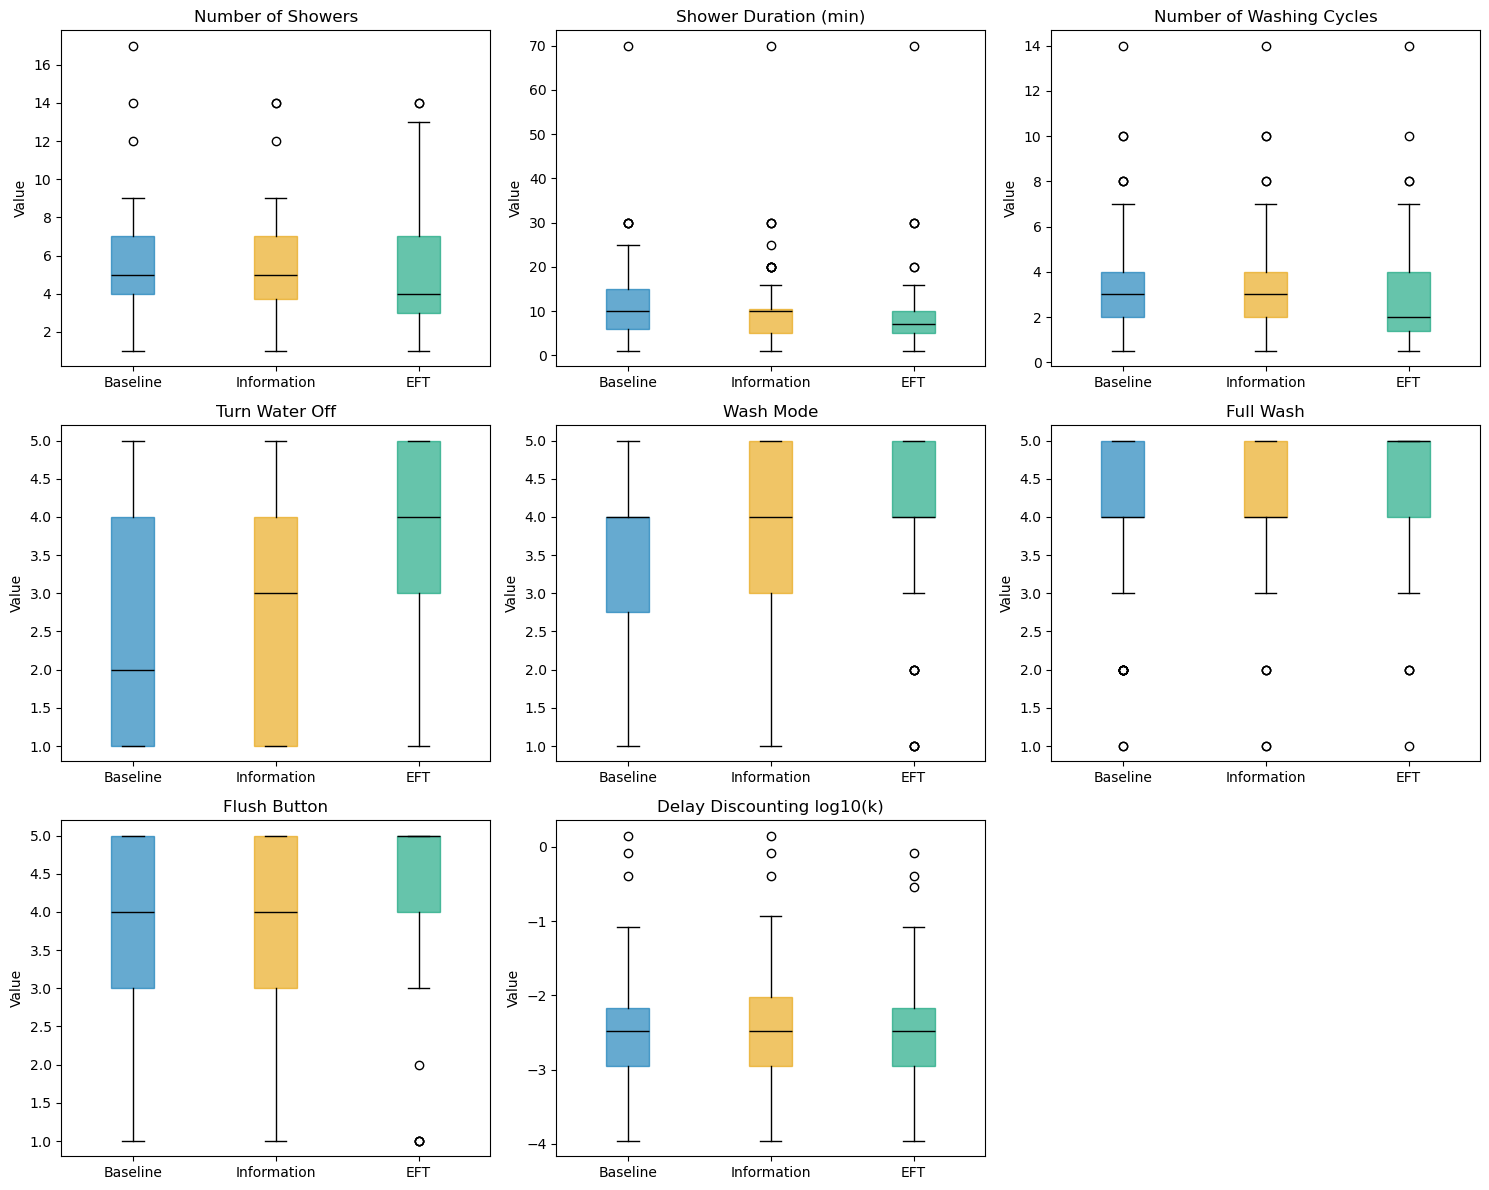

In [38]:
TimePointColors = {"T1": "#0072B2", "T2": "#E69F00", "T3": "#009E73"}

PlotTitles = {"NumberOfShowers": "Number of Showers", "ShowerDuration": "Shower Duration (min)",
              "NumberOfWashing": "Number of Washing Cycles", "Turnwateroff": "Turn Water Off", "WashMode": "Wash Mode",
              "FullWash": "Full Wash", "FlushButton": "Flush Button", "log10_k": "Delay Discounting log10(k)"}

VariablesToPlot = list(RepeatedMeasuresColumnMap.items())
NumberOfPlots = len(VariablesToPlot)
NumberOfColumns = 3
NumberOfRows = int(np.ceil(NumberOfPlots / NumberOfColumns))

Figure, AxesGrid = plt.subplots(
    NumberOfRows, NumberOfColumns, figsize=(5 * NumberOfColumns, 4 * NumberOfRows))
AxesGrid = AxesGrid.flatten()

for PlotIndex, (VariableName, ColumnsForVariable) in enumerate(VariablesToPlot):
    Axis = AxesGrid[PlotIndex]

    DataPerTimePoint = [
        pd.to_numeric(DataSet[ColumnsForVariable[TimePointLabel]], errors="coerce").dropna()
        for TimePointLabel in TimePointLabels
        if TimePointLabel in ColumnsForVariable
    ]
    LabelsPresent = [
        TimePointLabel for TimePointLabel in TimePointLabels
        if TimePointLabel in ColumnsForVariable
    ]
    BoxColors = [TimePointColors[TimePointLabel] for TimePointLabel in LabelsPresent]

    TickLabels = {"T1": "Baseline", "T2": "Information", "T3": "EFT"}
    BoxplotResult = Axis.boxplot(
        DataPerTimePoint, tick_labels=[TickLabels[t] for t in LabelsPresent], patch_artist=True
    )
    
    for Box, Color in zip(BoxplotResult["boxes"], BoxColors):
        Box.set_facecolor(Color)
        Box.set_alpha(0.6)
        Box.set_edgecolor(Color)
    for Median in BoxplotResult["medians"]:
        Median.set_color("black")

    Axis.set_title(PlotTitles.get(VariableName, VariableName))
    Axis.set_ylabel("Value")

for ExtraIndex in range(NumberOfPlots, len(AxesGrid)):
    Figure.delaxes(AxesGrid[ExtraIndex])

plt.tight_layout()
plt.savefig("overview_T1_T2_T3.pdf", dpi=300)
plt.show()